In [1]:
import os
import geopandas as gpd

# Change to project root before importing local src modules
os.chdir('../..')
from src.geoadmin import load_laraic, get_landbase_bymask, load_assessor_parcels_bygeom


In [2]:
import pandas as pd

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
NEARMAP_DIR  = '/Users/adamswietek/Downloads/USC_Nearmap_Sample_Data'
NEARMAP_TILE = f'{NEARMAP_DIR}/IMAGERY_SAMPLE_EPSG3857_Date20251005/Tiles.shp'

nearmap_tile     = gpd.read_file(NEARMAP_TILE)

In [4]:
fp = '/Users/adamswietek/Documents/PostDoc/data/raw_la/LACounty_Parcels.gdb'

CRS = gpd.read_file(fp, rows=1).crs
assessor_parcel = gpd.read_file(fp, mask = nearmap_tile.to_crs(CRS))

In [5]:
import geopandas as gpd
import glob, re, os

import matplotlib.pyplot as plt
import numpy as np
from shapely.affinity import translate
from sklearn.neighbors import BallTree

# Change to project root before importing local src modules
os.chdir('../..')

from src.geoadmin import load_laraic, get_landbase_bymask, load_assessor_parcels_bygeom

# ── Paths ──────────────────────────────────────────────────────────────────
NEARMAP_DIR  = '/Users/adamswietek/Downloads/USC_Nearmap_Sample_Data'
NEARMAP_TILE = f'{NEARMAP_DIR}/IMAGERY_SAMPLE_EPSG3857_Date20251005/Tiles.shp'
NEARMAP_AI   = f'{NEARMAP_DIR}/AI_SAMPLE'
NEARMAP_BLDG = f'{NEARMAP_AI}/ai_features_None_Building.gpkg'

nearmap_building = gpd.read_file(NEARMAP_BLDG)
nearmap_tile     = gpd.read_file(NEARMAP_TILE)

In [6]:
layer_files = sorted(glob.glob(f'{NEARMAP_AI}/ai_features_None_*.gpkg'))
# skip = re.compile(r'_Building.*|_Deprecated.*', re.IGNORECASE)
layer_files = [f for f in layer_files]# if not skip.search(os.path.basename(f))]

def layer_name(path):
    """ai_features_None_Roof_Rusting.gpkg  →  roof_rusting"""
    name = os.path.basename(path).replace('ai_features_None_', '').replace('.gpkg', '')
    return name.lower().replace('-', '_')

ai_cols = [layer_name(f) for f in layer_files]
print(f"Found {len(layer_files)} AI feature layers:")
for col in ai_cols:
    print(f"  {col}")

Found 23 AI feature layers:
  building
  building_deprecated
  dormer_window
  dutch_gable
  flat
  flat_deprecated
  gable
  hip
  leaf_off_tree_overhang
  metal
  missing_roof_tile_or_shingle
  roof
  roof_ponding
  roof_rusting
  roof_with_permanent_repair
  roof_with_temporary_repair
  shingle
  structural_damage
  tile
  tile_or_shingle_staining
  tree_overhang
  turret
  zinc_staining


In [7]:
# Reproject Nearmap buildings to the landbase CRS (EPSG:2229, NAD83 California zone 5 ft-US)
nm_proj = (nearmap_building[['id', 'areaSqft', 'clippedAreaSqft', 'geometry']]
           .copy()
           .to_crs(CRS))
print(f"nm_proj: {len(nm_proj):,} buildings  |  CRS: {nm_proj.crs}")

nm_proj: 5,321 buildings  |  CRS: EPSG:2229


In [8]:
# Estimate the systematic spatial shift between Nearmap buildings and landbase parcel centroids
# using nearest-neighbour matching. Only pairs within 200 ft are used to exclude bad matches.
lb_xy = np.column_stack([assessor_parcel.geometry.centroid.x, assessor_parcel.geometry.centroid.y])
nm_xy = np.column_stack([nm_proj.geometry.centroid.x, nm_proj.geometry.centroid.y])

tree = BallTree(lb_xy)
dist, idx = tree.query(nm_xy, k=1)

mask = dist[:, 0] < 200   # within 200 ft
dx = lb_xy[idx[mask, 0], 0] - nm_xy[mask, 0]
dy = lb_xy[idx[mask, 0], 1] - nm_xy[mask, 1]

OFFSET_X = float(np.median(dx))
OFFSET_Y = float(np.median(dy))

print(f"Pairs used : {mask.sum()}")
print(f"  dx  mean={dx.mean():.2f}  median={OFFSET_X:.2f}  std={dx.std():.2f}  ft")
print(f"  dy  mean={dy.mean():.2f}  median={OFFSET_Y:.2f}  std={dy.std():.2f}  ft")
print(f"\nApplied offset  →  dx={OFFSET_X:.2f} ft,  dy={OFFSET_Y:.2f} ft")

Pairs used : 5317
  dx  mean=5.13  median=8.17  std=14.93  ft
  dy  mean=-1.93  median=-2.07  std=33.33  ft

Applied offset  →  dx=8.17 ft,  dy=-2.07 ft


In [9]:
# Apply the offset to all Nearmap buildings — this is the authoritative aligned layer
nm = nm_proj.copy()
nm.geometry = nm.geometry.translate(xoff=OFFSET_X, yoff=OFFSET_Y)
nm = nm[['id', 'areaSqft', 'clippedAreaSqft', 'geometry']]
print(f"nm (aligned): {len(nm):,} buildings  |  CRS: {nm.crs}")
assessor_nm = gpd.overlay(nm, assessor_parcel, how='intersection')
assessor_nm['NM_BLDG_AREA'] = assessor_nm.geometry.area

nm (aligned): 5,321 buildings  |  CRS: EPSG:2229


In [10]:
lariac = load_laraic(nearmap_tile, 2020).to_crs('EPSG:2229')
lariac['poly'] = lariac.geometry
lariac_centroid = lariac.set_geometry(lariac.centroid)
assessor_lar = gpd.sjoin(lariac_centroid, assessor_parcel, how = 'inner')
assessor_lar['geom_area'] = assessor_lar.set_geometry('poly')['geometry'].area

ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/core.py:280: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read_info(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC6_Buildings_2020.gdb': 'LARIAC6_BUILDINGS_2020' (default), 'LARIAC5_BUILDINGS_DELETED_2020'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(pa

In [11]:
lar_poly = lariac[['geometry']]
nm_poly = nm[['geometry']]

# Union each dataset into a single coverage layer for differencing
lar_union = lar_poly.dissolve().reset_index(drop=True)
nm_union  = nm_poly.dissolve().reset_index(drop=True)

# NM footprint not covered by LARIAC
nm_only = gpd.overlay(nm_poly, lar_union[['geometry']], how='difference')
nm_only['sqft_nm_only'] = nm_only.geometry.area

# LARIAC footprint not covered by NM
lar_only = gpd.overlay(lar_poly, nm_union[['geometry']], how='difference')
lar_only['sqft_lar_only'] = lar_only.geometry.area

print(f"NM-only fragments : {len(nm_only):,}  |  total sqft: {nm_only['sqft_nm_only'].sum():,.0f}")
print(f"LAR-only fragments: {len(lar_only):,}  |  total sqft: {lar_only['sqft_lar_only'].sum():,.0f}")



NM-only fragments : 5,313  |  total sqft: 1,194,933
LAR-only fragments: 5,951  |  total sqft: 525,868


In [12]:
# ── Attribute differences to assessor parcels ─────────────────────────────────
# Drop tiny slivers (< 10 sqft) — alignment noise
nm_only_filt  = nm_only[nm_only['sqft_nm_only']  > 10].copy()
lar_only_filt = lar_only[lar_only['sqft_lar_only'] > 10].copy()

# Spatial join to parcel layer using centroid to avoid boundary issues
nm_only_ain = gpd.sjoin(
    nm_only_filt.set_geometry(nm_only_filt.geometry.centroid),
    assessor_parcel[['AIN', 'geometry']],
    how='left', predicate='within'
).rename(columns={'AIN': 'AIN'})

lar_only_ain = gpd.sjoin(
    lar_only_filt.set_geometry(lar_only_filt.geometry.centroid),
    assessor_parcel[['AIN', 'geometry']],
    how='left', predicate='within'
)

# Summarise per parcel
nm_missing_per_parcel  = nm_only_ain.groupby('AIN')['sqft_nm_only'].sum().rename('sqft_in_NM_not_LAR')
lar_missing_per_parcel = lar_only_ain.groupby('AIN')['sqft_lar_only'].sum().rename('sqft_in_LAR_not_NM')

parcel_diff = pd.concat([nm_missing_per_parcel, lar_missing_per_parcel], axis=1).fillna(0)
parcel_diff['net_nm_advantage'] = parcel_diff['sqft_in_NM_not_LAR'] - parcel_diff['sqft_in_LAR_not_NM']

print(f"Parcels with any difference: {len(parcel_diff):,}")
parcel_diff.describe()


Parcels with any difference: 3,313


,sqft_in_NM_not_LAR,sqft_in_LAR_not_NM,net_nm_advantage
count,3313.000000,3313.000000,3313.000000
mean,367.451259,259.801185,107.650075
std,578.657937,811.803609,967.908254
min,0.000000,0.000000,-13579.589200
25%,140.816494,49.180358,28.623885
50%,236.885668,90.322851,121.303814
75%,420.486336,153.173544,276.321261
max,17061.934960,13579.589200,17061.934960


In [13]:
# ── Structure counts & sqft from original (non-differenced) geometries ─────────
nm_per_parcel = (
    assessor_nm.groupby('AIN')
    .agg(n_nm=('id', 'count'), sqft_nm=('NM_BLDG_AREA', 'sum'))
)

lar_per_parcel = (
    assessor_lar.assign(sqft_lar=lambda d: d.set_geometry('poly').geometry.area)
    .groupby('AIN')
    .agg(n_lar=('AIN', 'count'), sqft_lar=('sqft_lar', 'sum'))
)

parcel_diff = parcel_diff.join(nm_per_parcel).join(lar_per_parcel).fillna(0).astype({
    'n_nm': int, 'n_lar': int,
})

parcel_diff = parcel_diff[[
    'n_nm', 'n_lar',
    'sqft_nm', 'sqft_lar',
    'sqft_in_NM_not_LAR', 'sqft_in_LAR_not_NM',
    'net_nm_advantage',
]]

print(parcel_diff.shape)
parcel_diff.sort_values('sqft_in_NM_not_LAR', ascending=False).head(20)


(3313, 7)


,n_nm,n_lar,sqft_nm,sqft_lar,sqft_in_NM_not_LAR,sqft_in_LAR_not_NM,net_nm_advantage
AIN,,,,,,,
5001015032,1,1,29169.024168,16057.439251,17061.934960,0.000000,17061.934960
5110006028,1,3,8617.984118,2887.639345,9370.209647,784.382441,8585.827207
5001026041,1,2,10597.161301,4003.147077,8460.301220,607.103910,7853.197310
5101030030,1,3,8160.584624,3481.143591,8204.655350,433.956495,7770.698854
5001029900,3,0,4603.398104,0.000000,7137.127683,0.000000,7137.127683
5110026033,1,1,9513.322355,4961.695939,5563.276153,545.574561,5017.701592
5001014033,1,1,11280.748481,6541.277702,5216.754107,0.000000,5216.754107
5111009919,14,12,63314.860257,59085.145537,4920.343047,673.969704,4246.373342
5111012030,1,1,5128.570369,353.126938,4881.770482,83.924617,4797.845865


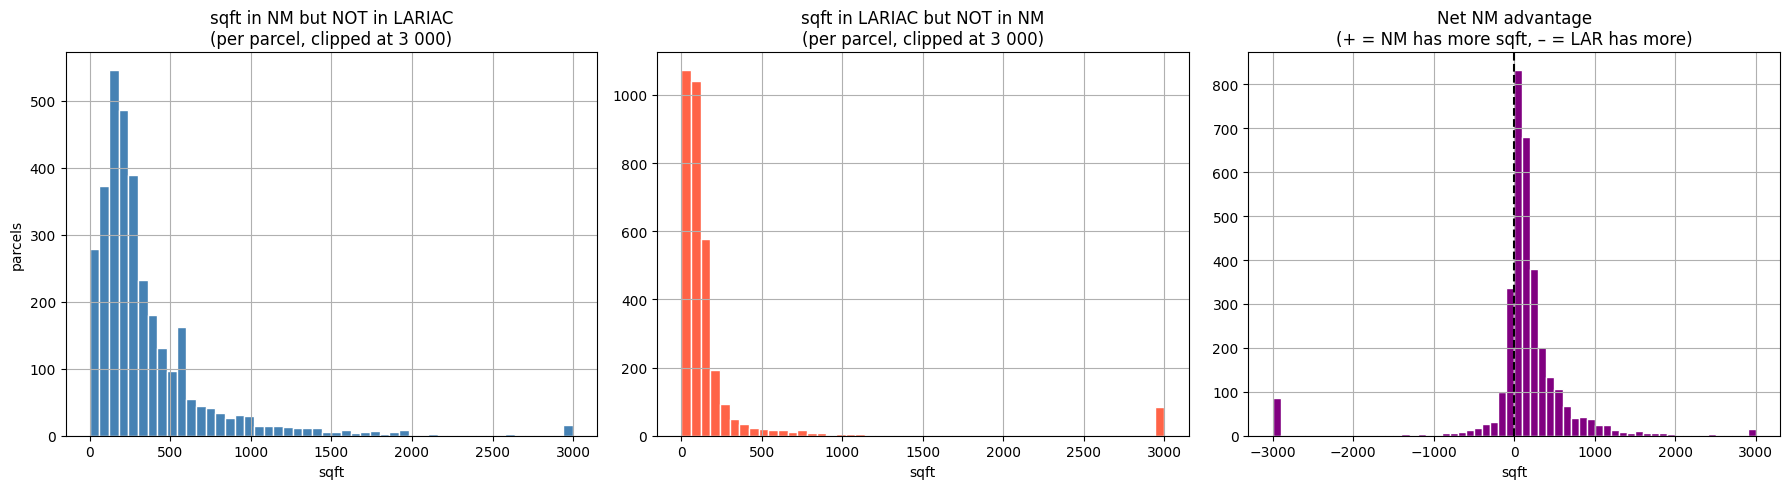


Top 20 parcels by sqft NM > LAR:


,n_nm,n_lar,sqft_nm,sqft_lar,sqft_in_NM_not_LAR,sqft_in_LAR_not_NM,net_nm_advantage
AIN,,,,,,,
5018030003,1,1,3197.342303,2849.372925,0.0,16.529283,-16.529283
5018033008,1,1,4184.390608,4088.319799,0.0,149.337533,-149.337533
5018034006,2,2,2233.183900,2593.293351,0.0,422.604815,-422.604815
5018036015,1,2,2544.584134,2500.357495,0.0,20.277845,-20.277845
5018037014,1,2,1934.989251,1686.047549,0.0,11.983545,-11.983545
5018037016,1,1,3973.327215,3743.420808,0.0,58.229584,-58.229584
5018037031,1,1,918.124611,876.529445,0.0,25.384627,-25.384627
5018037049,1,1,919.329959,922.647619,0.0,14.839611,-14.839611
5019006002,0,1,0.000000,6263.954329,0.0,6263.954329,-6263.954329


In [19]:
# ── Quick visual summary ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

parcel_diff['sqft_in_NM_not_LAR'].clip(upper=3000).hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('sqft in NM but NOT in LARIAC\n(per parcel, clipped at 3 000)')
axes[0].set_xlabel('sqft'); axes[0].set_ylabel('parcels')

parcel_diff['sqft_in_LAR_not_NM'].clip(upper=3000).hist(bins=50, ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('sqft in LARIAC but NOT in NM\n(per parcel, clipped at 3 000)')
axes[1].set_xlabel('sqft')

parcel_diff['net_nm_advantage'].clip(-3000, 3000).hist(bins=60, ax=axes[2], color='purple', edgecolor='white')
axes[2].axvline(0, color='black', lw=1.5, ls='--')
axes[2].set_title('Net NM advantage\n(+ = NM has more sqft, – = LAR has more)')
axes[2].set_xlabel('sqft')

plt.tight_layout()
plt.show()

# Top parcels where NM has substantially more coverage (likely hidden/missed structures)
print("\nTop 20 parcels by sqft NM > LAR:")
parcel_diff.sort_values('sqft_in_NM_not_LAR', ascending=False).tail(20)


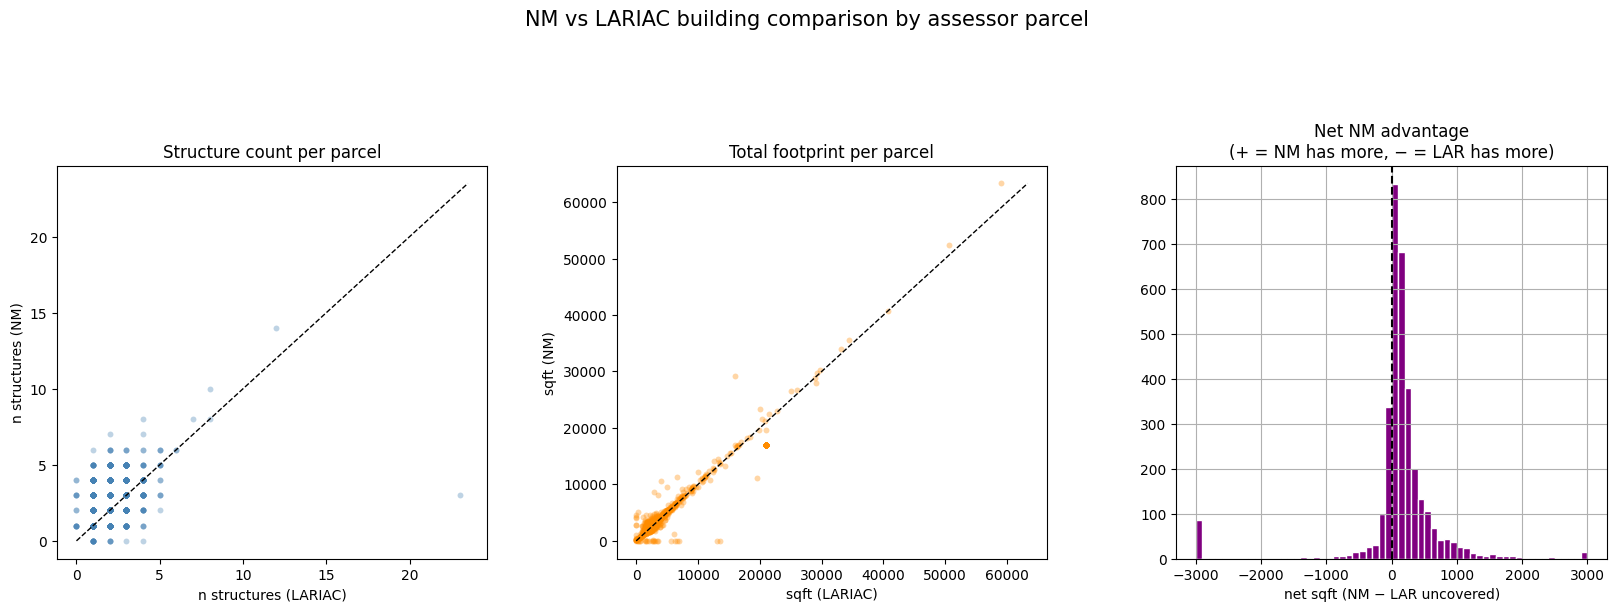

In [20]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Join parcel_diff back to geometry for mapping
parcel_map = assessor_parcel.set_index('AIN').join(parcel_diff, how='inner')

fig = plt.figure(figsize=(20, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# ── 1. Count scatter: n_nm vs n_lar ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(parcel_map['n_lar'], parcel_map['n_nm'],
            alpha=0.35, s=18, color='steelblue', linewidths=0)
lim = max(parcel_map[['n_nm','n_lar']].max()) + 0.5
ax1.plot([0, lim], [0, lim], 'k--', lw=1)
ax1.set_xlabel('n structures (LARIAC)')
ax1.set_ylabel('n structures (NM)')
ax1.set_title('Structure count per parcel')

# ── 2. Sqft scatter: sqft_nm vs sqft_lar ─────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(parcel_map['sqft_lar'], parcel_map['sqft_nm'],
            alpha=0.35, s=18, color='darkorange', linewidths=0)
lim2 = max(parcel_map[['sqft_nm','sqft_lar']].max())
ax2.plot([0, lim2], [0, lim2], 'k--', lw=1)
ax2.set_xlabel('sqft (LARIAC)')
ax2.set_ylabel('sqft (NM)')
ax2.set_title('Total footprint per parcel')

# ── 3. Net NM advantage histogram ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
parcel_map['net_nm_advantage'].clip(-3000, 3000).hist(bins=60, ax=ax3, color='purple', edgecolor='white')
ax3.axvline(0, color='black', lw=1.5, ls='--')
ax3.set_xlabel('net sqft (NM − LAR uncovered)')
ax3.set_title('Net NM advantage\n(+ = NM has more, − = LAR has more)')

# # ── 4. Map: net_nm_advantage per parcel ───────────────────────────────────────
# ax4 = fig.add_subplot(gs[1, :])
# vmax = parcel_map['net_nm_advantage'].abs().quantile(0.95)
# parcel_map.plot(
#     column='net_nm_advantage',
#     cmap='RdBu', vmin=-vmax, vmax=vmax,
#     linewidth=0.3, edgecolor='grey',
#     legend=True,
#     legend_kwds={'label': 'net sqft (NM − LAR)', 'shrink': 0.6},
#     ax=ax4
# )
# ax4.set_title('Spatial distribution of NM vs LARIAC footprint difference', fontsize=13)
# ax4.set_axis_off()

plt.suptitle('NM vs LARIAC building comparison by assessor parcel', fontsize=15, y=1.01)
plt.show()


In [21]:
sf_ains = assessor_parcel.query('UseDescription == "Single"').AIN.astype(str)

Text(0.5, 1.0, 'Net NM advantage per parcel \n(+ = NM has more, − = LAR has more)')

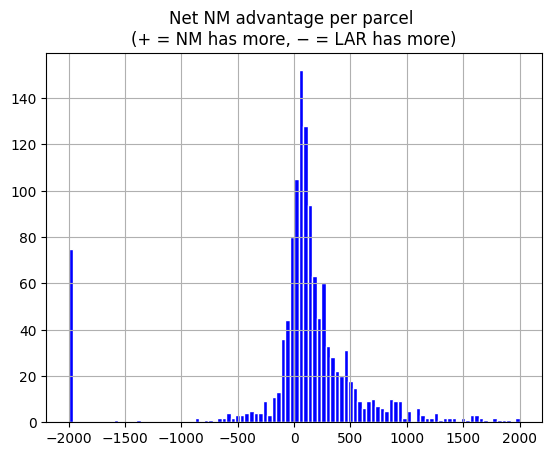

In [22]:
(parcel_map[parcel_map.index.isin(sf_ains)]['net_nm_advantage']
 .clip(-2000, 2000)
 .hist(bins=100, color='blue', edgecolor='white')
)
# plt.xscale('symlog')
plt.title('Net NM advantage per parcel \n(+ = NM has more, − = LAR has more)')

In [52]:
pd.merge(left = assessor_parcel[['AIN']], right = udu[['assessor_parcel_number']],
         left_on='AIN', right_on='assessor_parcel_number')

,AIN,assessor_parcel_number
0,5110033023,5110033023
1,5110006019,5110006019
2,5110031010,5110031010
3,5110031010,5110031010
4,5110033022,5110033022
5,5111015007,5111015007
6,5111023002,5111023002


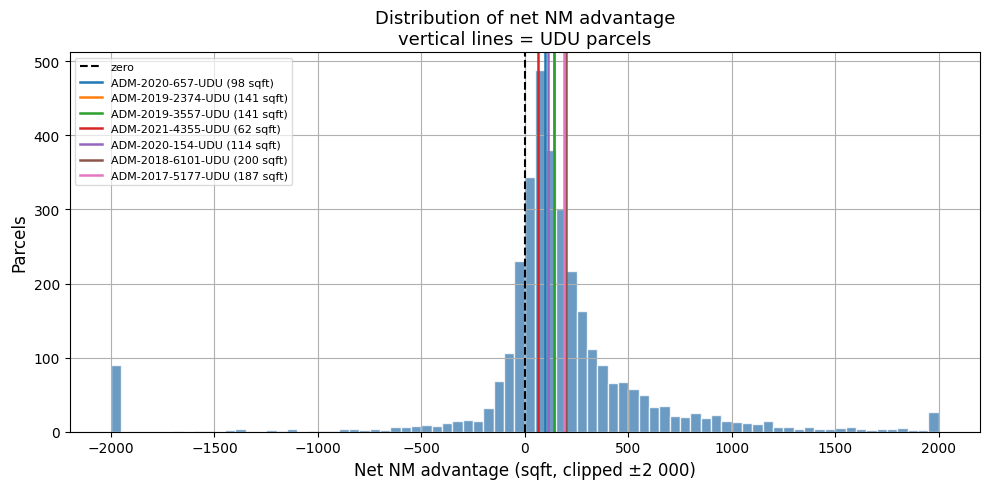

In [16]:

# ── Distribution of net_nm_advantage with UDU parcel highlights ───────────────
udu_merged = pd.merge(
    left=parcel_diff.reset_index(), left_on='AIN',
    right=udu, right_on='assessor_parcel_number',
    how='inner'
)

fig, ax = plt.subplots(figsize=(10, 5))

parcel_diff['net_nm_advantage'].clip(-2000, 2000).hist(
    bins=80, ax=ax, color='steelblue', edgecolor='white', alpha=0.8
)
ax.axvline(0, color='black', lw=1.5, ls='--', label='zero')

# One vertical line per UDU row, labelled by case_number
cmap = plt.cm.tab10.colors
for i, (_, row) in enumerate(udu_merged.iterrows()):
    ax.axvline(
        row['net_nm_advantage'],
        color=cmap[i % len(cmap)],
        lw=1.8,
        ls='-',
        label=f"{row['case_number']} ({row['net_nm_advantage']:.0f} sqft)"
    )

ax.set_xlabel('Net NM advantage (sqft, clipped ±2 000)', fontsize=12)
ax.set_ylabel('Parcels', fontsize=12)
ax.set_title('Distribution of net NM advantage\nvertical lines = UDU parcels', fontsize=13)
ax.legend(fontsize=8, loc='upper left', framealpha=0.7)
plt.tight_layout()
plt.show()


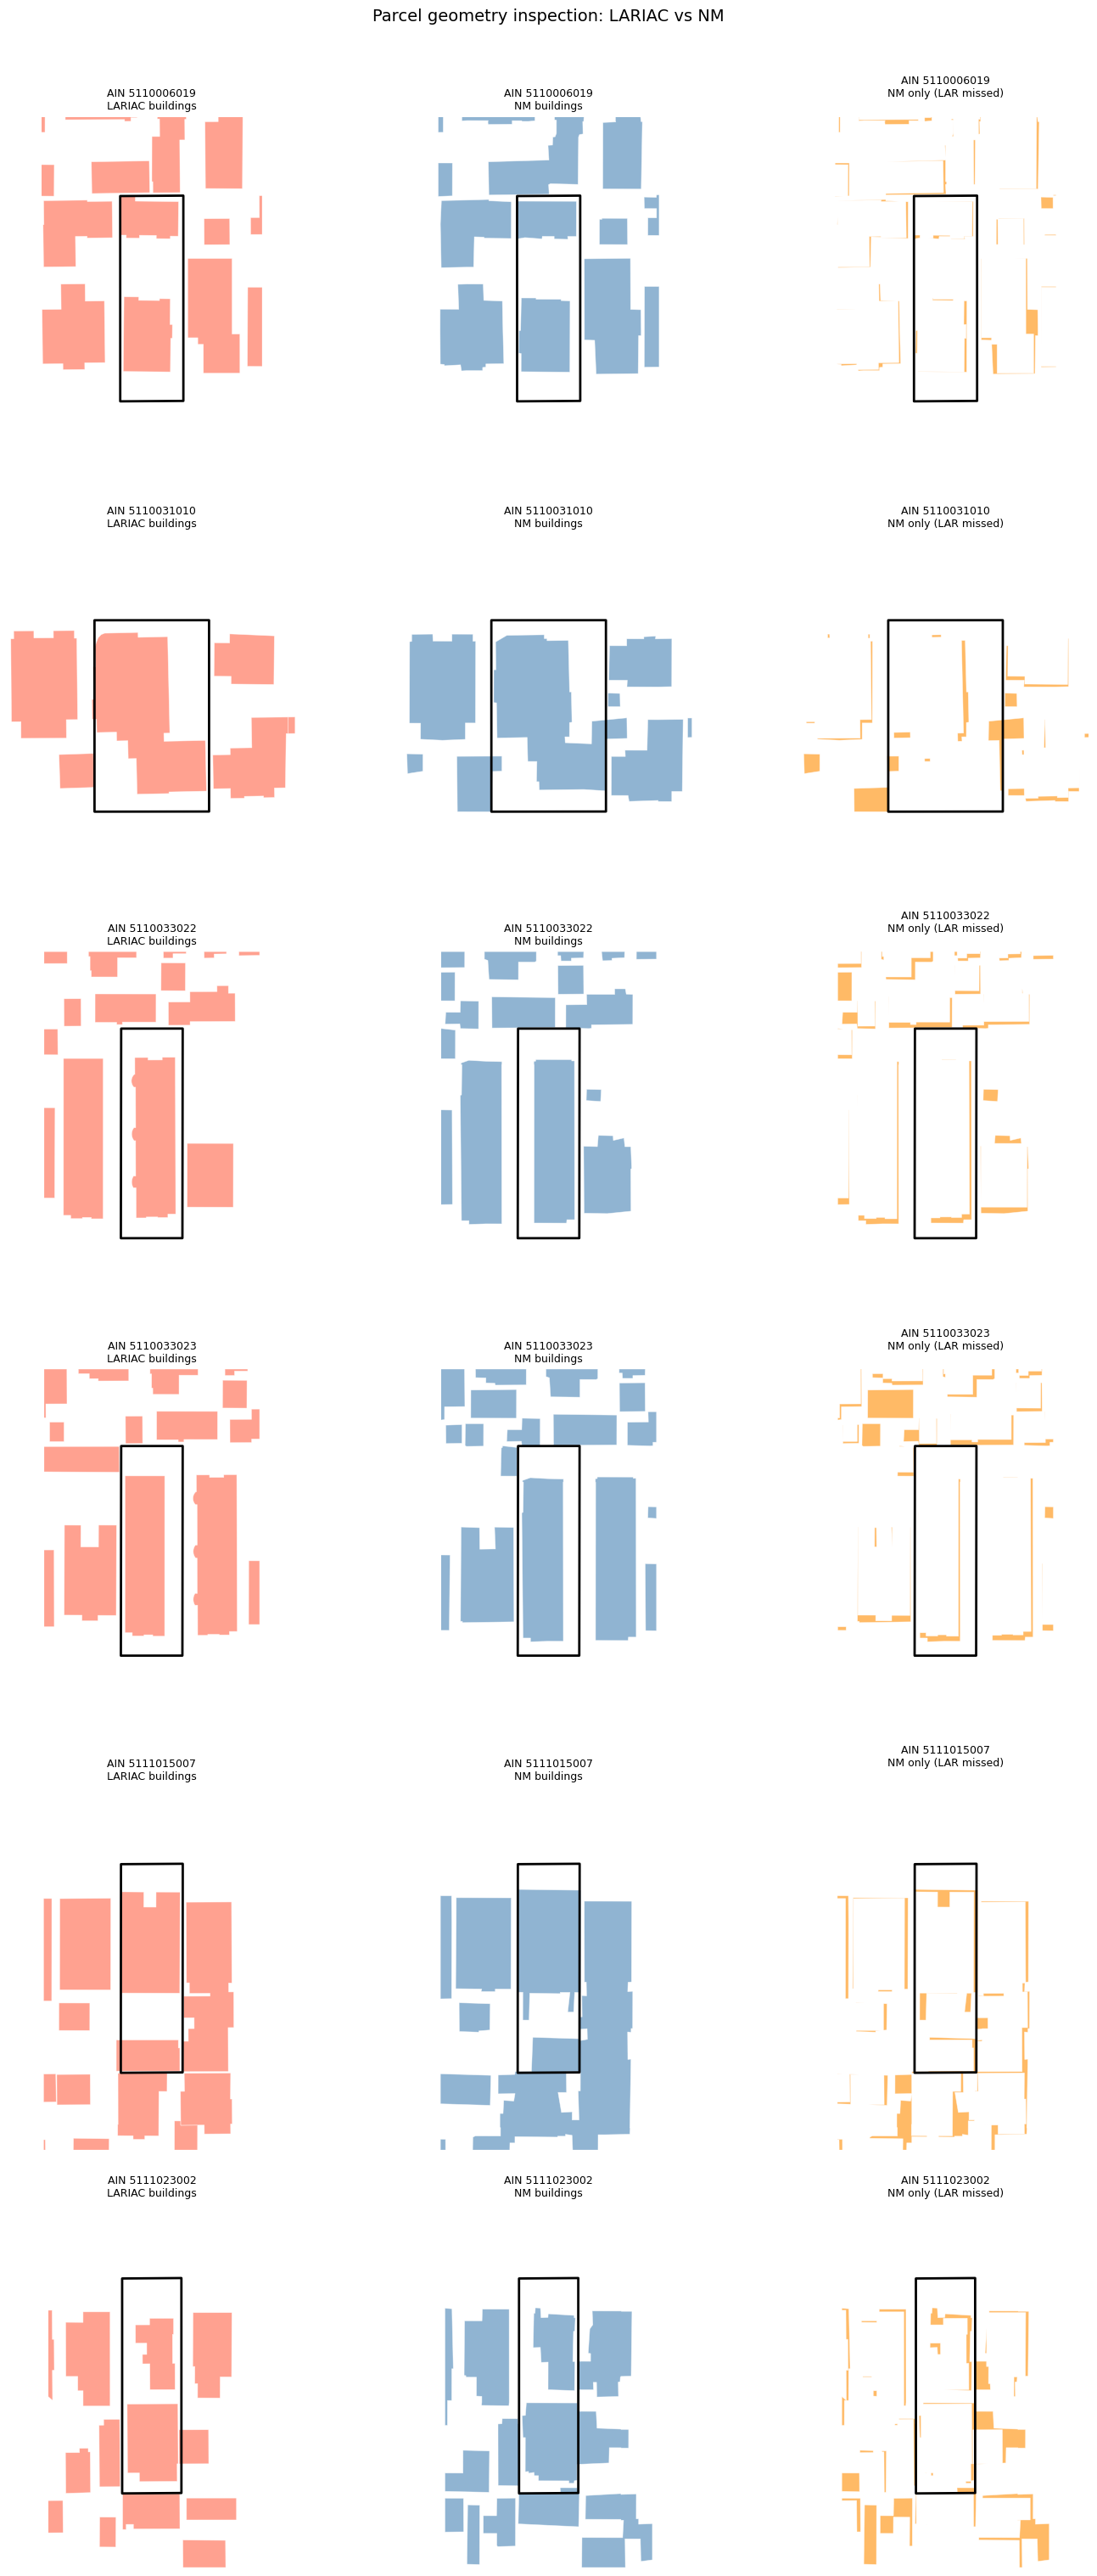

In [17]:
# ── Per-AIN geometry plots: parcel / LARIAC / NM / NM-only ───────────────────
unique_ains = udu_merged['AIN'].unique()
n = len(unique_ains)

fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
if n == 1:
    axes = axes[np.newaxis, :]  # keep 2-D indexing

for row_i, ain in enumerate(unique_ains):
    parcel_geom  = assessor_parcel[assessor_parcel['AIN'] == ain].to_crs('EPSG:2229')
    bounds       = parcel_geom.total_bounds          # minx, miny, maxx, maxy
    pad          = 50                                # ft padding around parcel

    # ── clip helpers ─────────────────────────────────────────────────────────
    from shapely.geometry import box
    clip_box = box(bounds[0]-pad, bounds[1]-pad, bounds[2]+pad, bounds[3]+pad)
    clip_gdf = gpd.GeoDataFrame(geometry=[clip_box], crs='EPSG:2229')

    lar_clip = gpd.clip(lariac.to_crs('EPSG:2229'), clip_gdf)
    nm_clip  = gpd.clip(nm,                         clip_gdf)
    nm_only_clip = gpd.clip(nm_only_filt,           clip_gdf)

    case_str = ', '.join(udu_merged.loc[udu_merged['AIN'] == ain, 'case_number'])

    for col_i, (title, bldg_gdf, bldg_color) in enumerate([
        ('LARIAC buildings',      lar_clip,      'tomato'),
        ('NM buildings',          nm_clip,       'steelblue'),
        ('NM only (LAR missed)',  nm_only_clip,  'darkorange'),
    ]):
        ax = axes[row_i, col_i]
        parcel_geom.plot(ax=ax, facecolor='none', edgecolor='black', lw=2, zorder=3)
        if len(bldg_gdf):
            bldg_gdf.plot(ax=ax, facecolor=bldg_color, edgecolor='white',
                          alpha=0.6, lw=0.5, zorder=2)
        ax.set_xlim(bounds[0]-pad, bounds[2]+pad)
        ax.set_ylim(bounds[1]-pad, bounds[3]+pad)
        ax.set_aspect('equal')
        ax.set_title(f'AIN {ain}\n{title}', fontsize=9)
        ax.set_axis_off()
        if col_i == 0:
            ax.set_ylabel(case_str, fontsize=7, rotation=0, labelpad=60, va='center')

plt.suptitle('Parcel geometry inspection: LARIAC vs NM', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [14]:
import pandas as pd
fp = "/Users/adamswietek/Documents/PostDoc/HiddenHousing/data/01_raw/UDU Report 02_10_2026 Download.csv"
udu = pd.read_csv(fp)

In [58]:
pd.merge(
    left = parcel_diff, left_on='AIN',
    right = udu , right_on = 'assessor_parcel_number',
    how = 'inner'
)

,n_nm,n_lar,sqft_nm,sqft_lar,sqft_in_NM_not_LAR,sqft_in_LAR_not_NM,net_nm_advantage,case_number,assessor_parcel_number,general_plan_land_use,community_plan_area,specific_plan,filing_date,case_completion_date,Approved Units
0,2,2,2321.068779,2233.765916,151.367384,53.776857,97.590527,ADM-2020-657-UDU,5110006019,Low Medium I Residential,Southeast Los Angeles,South Los Angeles Alcohol Sales,2020-01-30 00:00:00,2022-02-10 00:00:00,1.0
1,2,1,3902.405167,3850.997046,494.343554,353.637072,140.706482,ADM-2019-2374-UDU,5110031010,Low Medium I Residential,Southeast Los Angeles,"South Los Angeles Alcohol Sales,South Los Ange...",2019-04-19 00:00:00,2024-11-14 00:00:00,NaN
2,2,1,3902.405167,3850.997046,494.343554,353.637072,140.706482,ADM-2019-3557-UDU,5110031010,Low Medium I Residential,Southeast Los Angeles,"South Los Angeles Alcohol Sales,South Los Ange...",2019-06-14 00:00:00,2019-08-13 00:00:00,NaN
3,1,1,2782.318789,2720.340422,244.027593,182.049226,61.978367,ADM-2021-4355-UDU,5110033022,Low Medium II Residential,Southeast Los Angeles,South Los Angeles Alcohol Sales,2021-05-21 00:00:00,2021-05-27 00:00:00,NaN
4,2,1,2786.584222,2671.664309,204.228901,90.017091,114.211809,ADM-2020-154-UDU,5110033023,Low Medium II Residential,Southeast Los Angeles,South Los Angeles Alcohol Sales,2018-03-23 00:00:00,2022-01-14 00:00:00,1.0
5,2,2,3478.703730,3228.315194,447.326449,246.961190,200.365259,ADM-2018-6101-UDU,5111015007,Low Medium I Residential,Southeast Los Angeles,South Los Angeles Alcohol Sales,2017-09-22 00:00:00,2017-10-12 00:00:00,NaN
6,5,2,3099.677044,2679.533934,266.790760,79.510976,187.279785,ADM-2017-5177-UDU,5111023002,Low Medium II Residential,Southeast Los Angeles,South Los Angeles Alcohol Sales,2017-07-04 00:00:00,2017-08-01 00:00:00,2.0


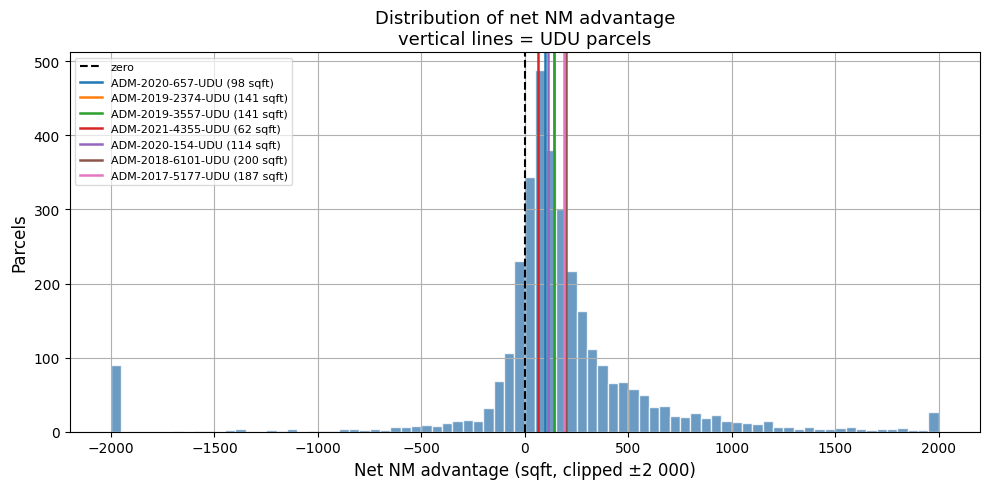

In [59]:

# ── Distribution of net_nm_advantage with UDU parcel highlights ───────────────
udu_merged = pd.merge(
    left=parcel_diff.reset_index(), left_on='AIN',
    right=udu, right_on='assessor_parcel_number',
    how='inner'
)

fig, ax = plt.subplots(figsize=(10, 5))

parcel_diff['net_nm_advantage'].clip(-2000, 2000).hist(
    bins=80, ax=ax, color='steelblue', edgecolor='white', alpha=0.8
)
ax.axvline(0, color='black', lw=1.5, ls='--', label='zero')

# One vertical line per UDU row, labelled by case_number
cmap = plt.cm.tab10.colors
for i, (_, row) in enumerate(udu_merged.iterrows()):
    ax.axvline(
        row['net_nm_advantage'],
        color=cmap[i % len(cmap)],
        lw=1.8,
        ls='-',
        label=f"{row['case_number']} ({row['net_nm_advantage']:.0f} sqft)"
    )

ax.set_xlabel('Net NM advantage (sqft, clipped ±2 000)', fontsize=12)
ax.set_ylabel('Parcels', fontsize=12)
ax.set_title('Distribution of net NM advantage\nvertical lines = UDU parcels', fontsize=13)
ax.legend(fontsize=8, loc='upper left', framealpha=0.7)
plt.tight_layout()
plt.show()


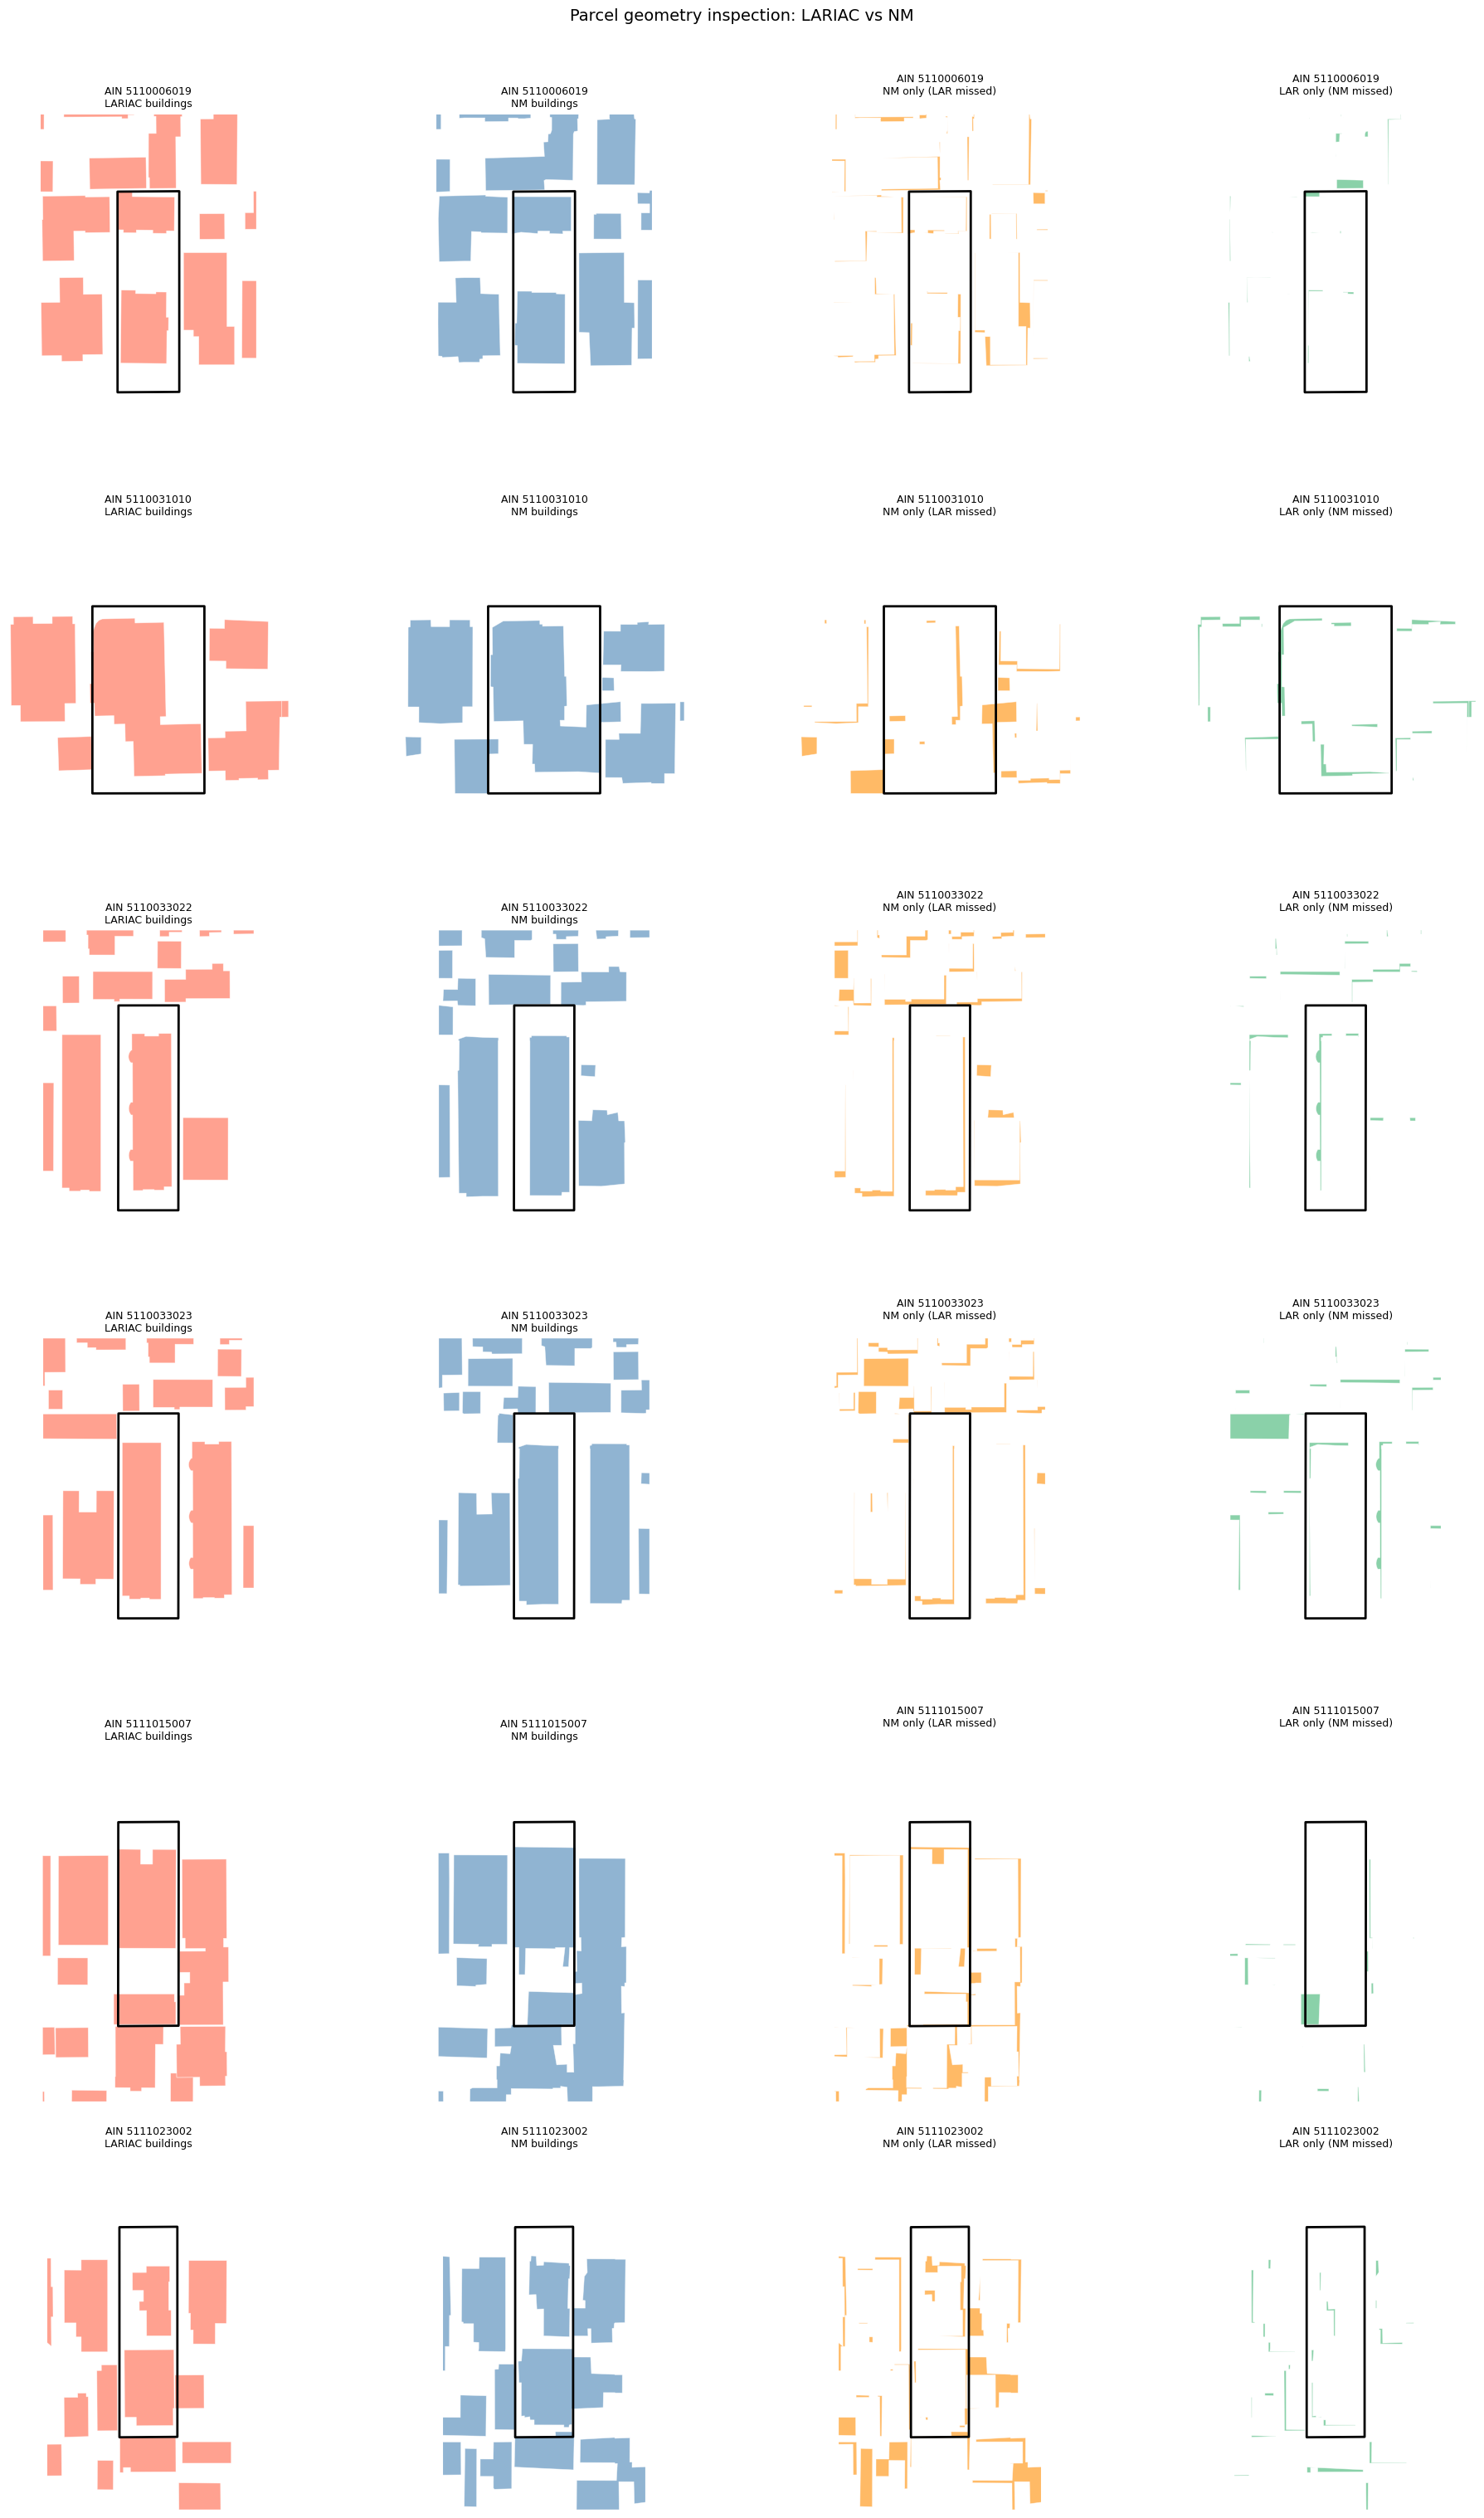

In [18]:

# ── Per-AIN geometry plots: parcel / LARIAC / NM / NM-only / LAR-only ────────
unique_ains = udu_merged['AIN'].unique()
n = len(unique_ains)

fig, axes = plt.subplots(n, 4, figsize=(20, 5 * n))
if n == 1:
    axes = axes[np.newaxis, :]  # keep 2-D indexing

for row_i, ain in enumerate(unique_ains):
    parcel_geom  = assessor_parcel[assessor_parcel['AIN'] == ain].to_crs('EPSG:2229')
    bounds       = parcel_geom.total_bounds
    pad          = 50                                # ft padding around parcel

    from shapely.geometry import box
    clip_box = box(bounds[0]-pad, bounds[1]-pad, bounds[2]+pad, bounds[3]+pad)
    clip_gdf = gpd.GeoDataFrame(geometry=[clip_box], crs='EPSG:2229')

    lar_clip      = gpd.clip(lariac.to_crs('EPSG:2229'), clip_gdf)
    nm_clip       = gpd.clip(nm,            clip_gdf)
    nm_only_clip  = gpd.clip(nm_only_filt,  clip_gdf)
    lar_only_clip = gpd.clip(lar_only_filt, clip_gdf)

    case_str = ', '.join(udu_merged.loc[udu_merged['AIN'] == ain, 'case_number'])

    for col_i, (title, bldg_gdf, bldg_color) in enumerate([
        ('LARIAC buildings',       lar_clip,       'tomato'),
        ('NM buildings',           nm_clip,        'steelblue'),
        ('NM only (LAR missed)',   nm_only_clip,   'darkorange'),
        ('LAR only (NM missed)',   lar_only_clip,  'mediumseagreen'),
    ]):
        ax = axes[row_i, col_i]
        parcel_geom.plot(ax=ax, facecolor='none', edgecolor='black', lw=2, zorder=3)
        if len(bldg_gdf):
            bldg_gdf.plot(ax=ax, facecolor=bldg_color, edgecolor='white',
                          alpha=0.6, lw=0.5, zorder=2)
        ax.set_xlim(bounds[0]-pad, bounds[2]+pad)
        ax.set_ylim(bounds[1]-pad, bounds[3]+pad)
        ax.set_aspect('equal')
        ax.set_title(f'AIN {ain}\n{title}', fontsize=9)
        ax.set_axis_off()
        if col_i == 0:
            ax.set_ylabel(case_str, fontsize=7, rotation=0, labelpad=60, va='center')

plt.suptitle('Parcel geometry inspection: LARIAC vs NM', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
